In [1]:
import numpy as np
import pandas as pd

In [2]:
import scipy as sp
import scipy.stats as stats

### Оценки центрального положения

In [3]:
data = np.random.randint(1, 100, 10000)
data

array([28, 73, 23, ..., 73, 51, 16], shape=(10000,))

In [4]:
weights = np.random.randint(1, 5, 10000)
weights

array([4, 4, 2, ..., 2, 4, 4], shape=(10000,))

#### Среднее

In [5]:
print(data.mean())

50.1294


In [6]:
print(data.sum() / len(data))

50.1294


In [66]:
print(np.mean(data))

50.1294


#### Среднее взвешенное

In [7]:
print(np.average(data, weights=weights))

50.33124975116455


In [8]:
print((data * weights).sum() / weights.sum())

50.33124975116455


#### Медиана

In [9]:
print(np.median(data))

50.0


In [10]:
print(np.percentile(data, 50))

50.0


#### Взвешенная медиана

In [11]:
df = pd.DataFrame(data={'value': data, 'weight': weights})
df

,value,weight
0,28,4
1,73,4
2,23,2
3,23,2
4,8,2
...,...,...
9995,11,4
9996,87,3
9997,73,2
9998,51,4


In [12]:
df = df.sort_values(by='value')
df

,value,weight
2352,1,2
6316,1,4
1415,1,3
6327,1,1
4169,1,2
...,...,...
6970,99,2
4902,99,4
6964,99,1
1229,99,2


In [13]:
df['cum_weight'] = df['weight'].cumsum()

In [14]:
df

,value,weight,cum_weight
2352,1,2,2
6316,1,4,6
1415,1,3,9
6327,1,1,10
4169,1,2,12
...,...,...,...
6970,99,2,25109
4902,99,4,25113
6964,99,1,25114
1229,99,2,25116


In [15]:
df['cum_weight_share'] = df['cum_weight'] / df['weight'].sum()
df

,value,weight,cum_weight,cum_weight_share
2352,1,2,2,0.000080
6316,1,4,6,0.000239
1415,1,3,9,0.000358
6327,1,1,10,0.000398
4169,1,2,12,0.000478
...,...,...,...,...
6970,99,2,25109,0.999681
4902,99,4,25113,0.999841
6964,99,1,25114,0.999881
1229,99,2,25116,0.999960


In [16]:
df.loc[df['cum_weight_share'].between(0.4999, 0.5011, inclusive='both')]

,value,weight,cum_weight,cum_weight_share
9527,51,3,12557,0.499940
9228,51,4,12561,0.500100
5616,51,2,12563,0.500179
96,51,4,12567,0.500338
9070,51,4,12571,0.500498
5444,51,1,12572,0.500537
7317,51,3,12575,0.500657
5070,51,3,12578,0.500776
2382,51,1,12579,0.500816
5218,51,2,12581,0.500896


In [17]:
print(np.percentile(data, 50, method='inverted_cdf', weights=weights))

51


In [18]:
def weighted_median(data, weights):
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]
    weights_cum = np.cumsum(weights_sorted)
    cutoff = 0.5 * weights_cum[-1]
    idx = np.searchsorted(weights_cum, cutoff)
    return data_sorted[idx], idx, cutoff

In [19]:
print(weighted_median(data, weights))

(np.int64(51), np.int64(5018), np.float64(12558.5))


#### Среднее усеченное

In [20]:
data

array([28, 73, 23, ..., 73, 51, 16], shape=(10000,))

In [21]:
data_sorted = np.sort(data)

In [22]:
data

array([28, 73, 23, ..., 73, 51, 16], shape=(10000,))

In [23]:
data_sorted

array([ 1,  1,  1, ..., 99, 99, 99], shape=(10000,))

In [24]:
def trimmed_mean(data, p_num):
    data_sorted = np.sort(data)
    return data_sorted[p_num: len(data_sorted) - p_num].mean()

In [25]:
print(trimmed_mean(data, 50))

50.13070707070707


In [26]:
def trimmed_mean_frac(data, p_frac):
    data_sorted = np.sort(data)
    idx = int(len(data_sorted) * p_frac)
    return data_sorted[idx: len(data_sorted) - idx].mean()

In [27]:
print(trimmed_mean_frac(data, 0.1))

50.19775


In [28]:
50/10000

0.005

In [29]:
print(trimmed_mean_frac(data, 0.005))

50.13070707070707


In [30]:
print(stats.trim_mean(data, 0.005))

50.13070707070707


In [31]:
data

array([28, 73, 23, ..., 73, 51, 16], shape=(10000,))

In [32]:
print(stats.trimboth(data, 0.005).mean())

50.13070707070707


In [33]:
data

array([28, 73, 23, ..., 73, 51, 16], shape=(10000,))

### Оценка вариабельности

#### Среднее абсолютное отклонение

In [34]:
data

array([28, 73, 23, ..., 73, 51, 16], shape=(10000,))

In [35]:
m = data.mean()

In [36]:
print(m)

50.1294


In [37]:
print(np.abs(data - m).mean())

24.635832920000002


In [38]:
print(np.abs(data - data.mean()).mean())

24.635832920000002


#### Медианное абсолютное отклонение от медианы

In [39]:
print(np.percentile(np.abs(data - np.percentile(data, 50)), 50))

25.0


In [40]:
print(np.median(np.abs(data - np.median(data))))

25.0


In [41]:
print(stats.median_abs_deviation(data))

25.0


#### Размах

In [42]:
print(data.max() - data.min())

98


#### Межквартильный размах

In [43]:
print(np.percentile(data, 75) - np.percentile(data, 25))

50.0


In [44]:
s = pd.Series(data)
s

0       28
1       73
2       23
3       23
4        8
        ..
9995    11
9996    87
9997    73
9998    51
9999    16
Length: 10000, dtype: int64

In [45]:
print(s.quantile(0.75) - s.quantile(0.25))

50.0


In [46]:
print(np.percentile(data, 75), s.quantile(0.75), sep=', ')

75.0, 75.0


#### Дисперсия и стандартное отклонение

In [47]:
print(data.var(ddof=1))

811.0287585158517


In [48]:
print(data.std(ddof=1))

28.478566651358204


In [49]:
print(np.sqrt(data.var(ddof=1)))

28.478566651358204


In [50]:
s = pd.Series(data)
s

0       28
1       73
2       23
3       23
4        8
        ..
9995    11
9996    87
9997    73
9998    51
9999    16
Length: 10000, dtype: int64

In [51]:
print(s.var())

811.0287585158432


In [52]:
print(s.std())

28.478566651358054


#### Коробочные диаграммы и другие визуализации

In [53]:
s = pd.Series(data)

<Axes: >

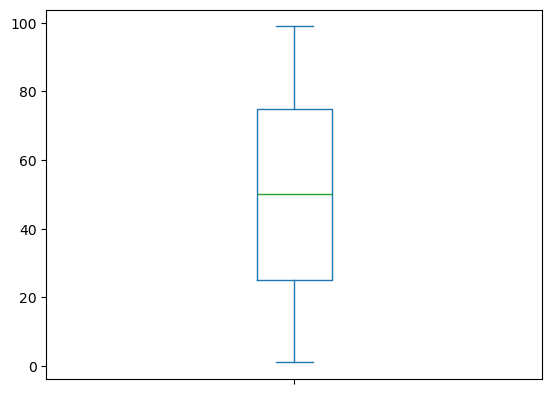

In [54]:
s.plot.box()

<Axes: ylabel='Frequency'>

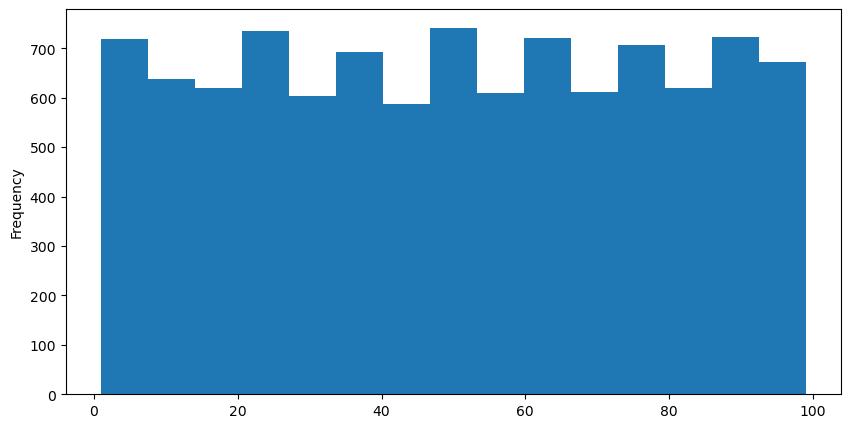

In [55]:
s.plot.hist(bins=15, figsize=(10, 5))

<Axes: ylabel='Density'>

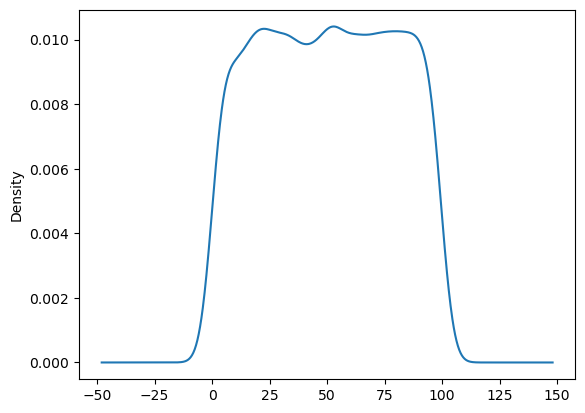

In [56]:
s.plot.density()

<Axes: ylabel='Density'>

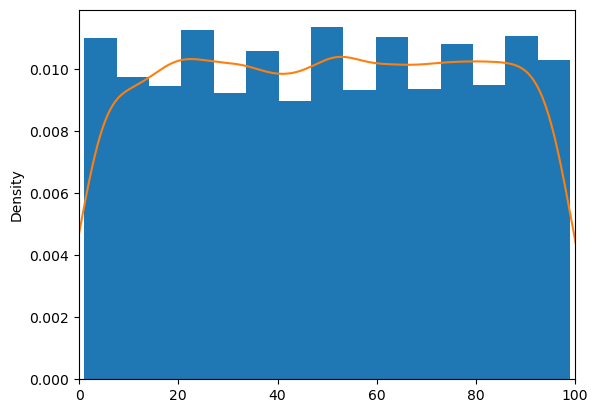

In [57]:
ax = s.plot.hist(density=True, xlim=[0, 100], bins=15)
s.plot.density(ax=ax)

#### Корреляция

In [58]:
df = pd.DataFrame(data={'value': data, 'weight': weights})
df.head()

,value,weight
0,28,4
1,73,4
2,23,2
3,23,2
4,8,2


In [59]:
df.corr()

,value,weight
value,1.000000,0.015889
weight,0.015889,1.000000


In [60]:
import seaborn as sns

<Axes: >

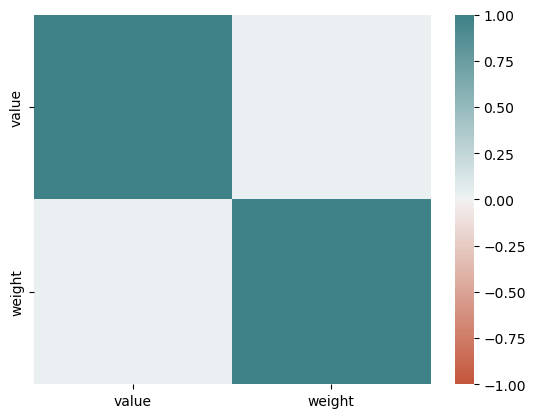

In [61]:
sns.heatmap(df.corr(), vmin=-1, vmax=1, cmap=sns.diverging_palette(20, 200, as_cmap=True))

<Axes: xlabel='weight', ylabel='value'>

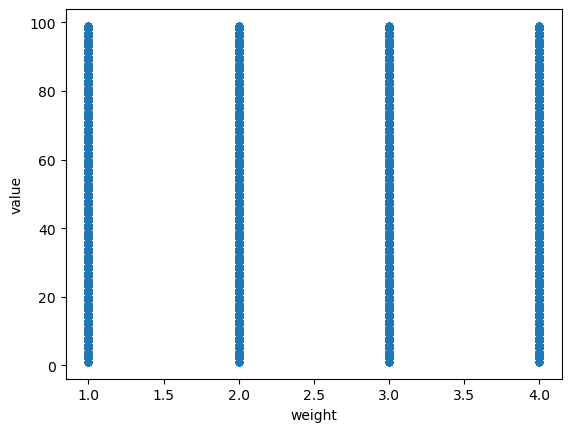

In [62]:
df.plot.scatter(x='weight', y='value')

<Axes: xlabel='weight', ylabel='value'>

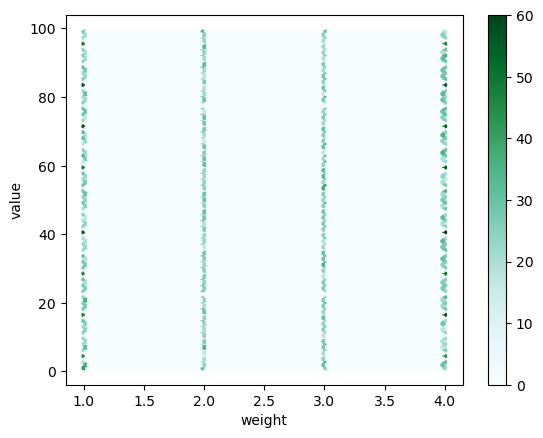

In [63]:
df.plot.hexbin(x='weight', y='value')

<Axes: xlabel='weight', ylabel='value'>

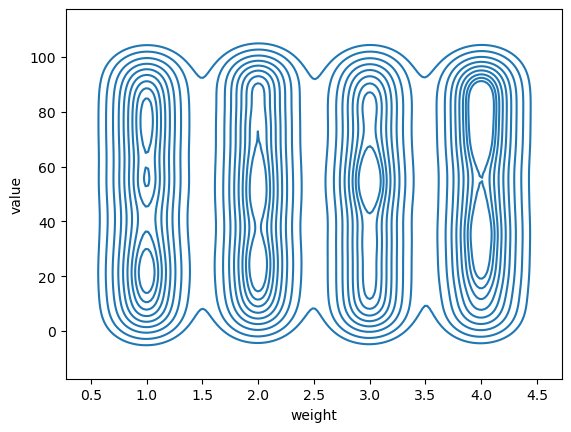

In [64]:
sns.kdeplot(x=df['weight'], y=df['value'])

#### Стандартная ошибка
Обобщает вариабельность статистической величины в выборочном распределении.

Для среднего есть оценка: SE = sigma (стандартное отклонение ген. совокупности) / sqrt(n).

Если sigma неизвестна, то его заменяют стандратным отклонением по выборке.

#### Бутстрап

In [69]:
data.size

10000

In [70]:
def bootstrap_stat(data, func, n_boot):
    results = np.empty(n_boot)
    for i in range(n_boot):
        resampled = np.random.choice(data, size=data.size, replace=True)
        results[i] = func(resampled)
    return results
    

In [71]:
print(np.median(data))

50.0


In [72]:
res = bootstrap_stat(data, np.median, 10000)

In [73]:
res

array([50., 51., 50., ..., 51., 50., 51.], shape=(10000,))

In [74]:
ci_low, ci_high = np.quantile(res, [0.025, 0.975])
print(ci_low, ci_high)

49.0 51.0


In [75]:
ci_low, ci_high = np.percentile(res, [2.5, 97.5])
print(ci_low, ci_high)

49.0 51.0


In [76]:
res = bootstrap_stat(data, np.mean, 10000)

In [77]:
res

array([49.7171, 49.9113, 50.3887, ..., 50.2621, 50.2725, 50.061 ],
      shape=(10000,))

In [79]:
ci_low, ci_high = np.quantile(res, [0.025, 0.975])
print(ci_low, ci_high)

49.5603775 50.6891225


In [78]:
ci_low, ci_high = np.percentile(res, [2.5, 97.5])
print(ci_low, ci_high)

49.5603775 50.6891225


In [82]:
res = stats.bootstrap(data=(data,), statistic=np.median, n_resamples=10000, method='percentile', confidence_level=0.95)
print(res)

BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(49.0), high=np.float64(51.0)), bootstrap_distribution=array([50. , 50. , 51. , ..., 50. , 50.5, 51. ], shape=(10000,)), standard_error=np.float64(0.5734137056504517))


In [87]:
res = stats.bootstrap(data=(data,), statistic=np.mean, n_resamples=10000, method='percentile', confidence_level=0.95)
print(res)

BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(49.5641), high=np.float64(50.69242)), bootstrap_distribution=array([50.2979, 49.8102, 50.0968, ..., 49.8197, 49.8862, 49.8737],
      shape=(10000,)), standard_error=np.float64(0.2865888358048484))


In [95]:
data

array([28, 73, 23, ..., 73, 51, 16], shape=(10000,))

In [96]:
idx = np.random.randint(0, data.size, (3, 2))
idx

array([[4126, 7412],
       [2436, 5777],
       [8409, 1322]])

In [97]:
data[idx]

array([[13, 13],
       [71, 11],
       [48, 33]])

In [103]:
data[
    [[4126, 7412],
    [2436, 5777]]
]

array([[13, 13],
       [71, 11]])

#### Нормальное распределение

In [105]:
import matplotlib.pyplot as plt

In [106]:
x = np.linspace(-4, 4, 1000)

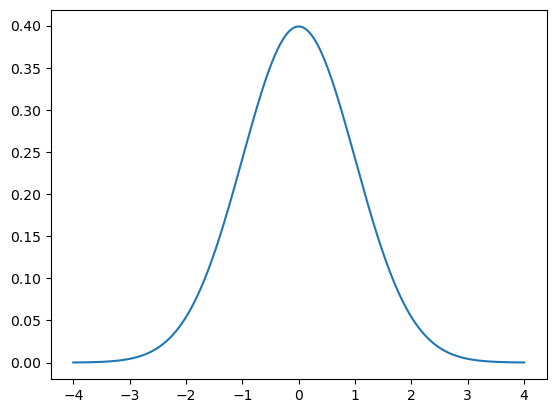

In [107]:
plt.plot(x, stats.norm.pdf(x, loc=0, scale=1))

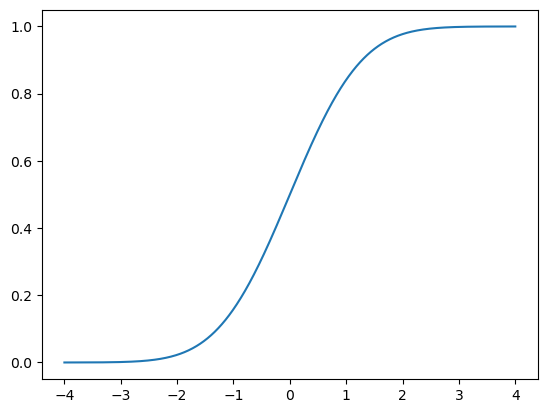

In [108]:
plt.plot(x, stats.norm.cdf(x, loc=0, scale=1))

#### Распределение Стьюдента

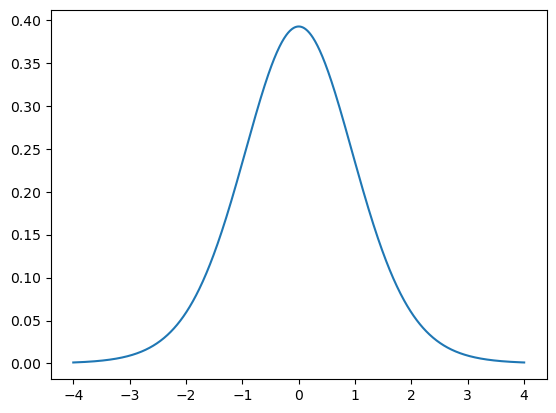

In [115]:
plt.plot(x, stats.t.pdf(x, loc=0, scale=1, df=15))

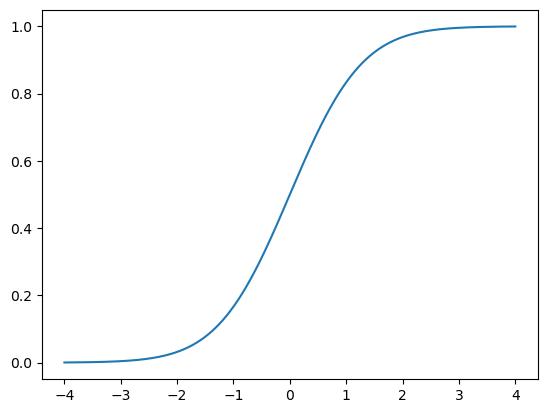

In [116]:
plt.plot(x, stats.t.cdf(x, loc=0, scale=1, df=15))

#### Биномиальное распределение

In [118]:
n = 20
p = 0.3
x = np.arange(0, n + 1)

<BarContainer object of 21 artists>

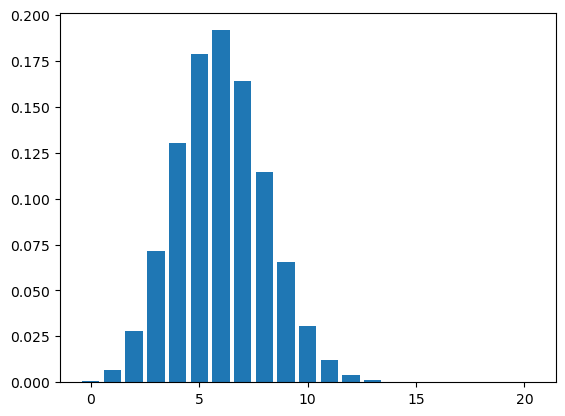

In [120]:
plt.bar(x, stats.binom.pmf(x, n, p))

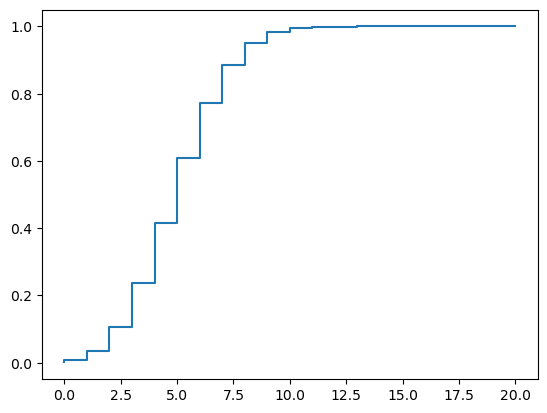

In [121]:
plt.step(x, stats.binom.cdf(x, n, p))

#### Распределение Хи-квадрат

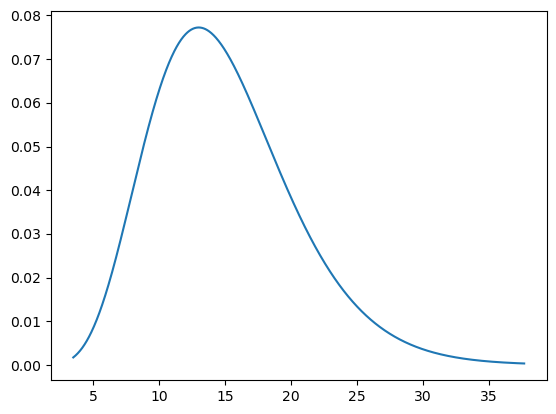

In [123]:
df = 15
x = np.linspace(stats.chi2.ppf(0.001, df), stats.chi2.ppf(0.999, df), 1000)
plt.plot(x, stats.chi2.pdf(x, df=df))

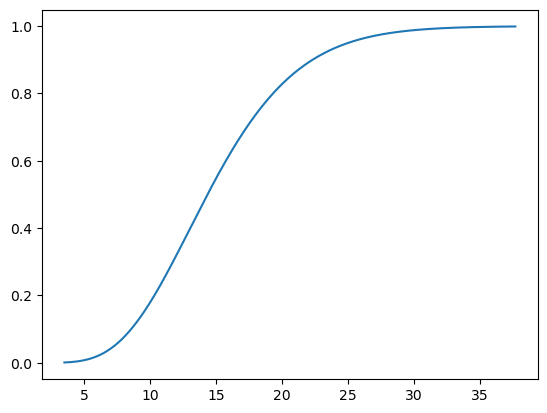

In [124]:
plt.plot(x, stats.chi2.cdf(x, df=df))

#### Распределение Пуассона

<BarContainer object of 15 artists>

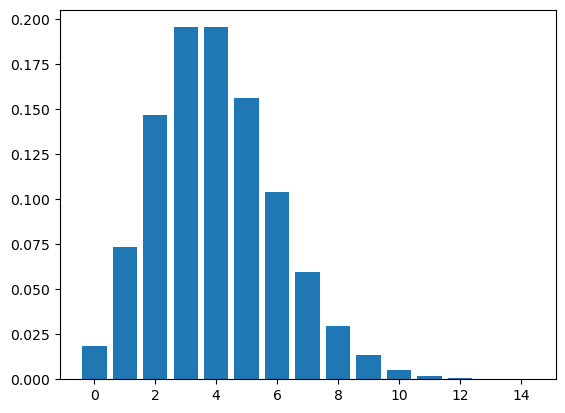

In [125]:
x = np.arange(0, 15)
lam = 4
plt.bar(x, stats.poisson.pmf(x, mu=lam))

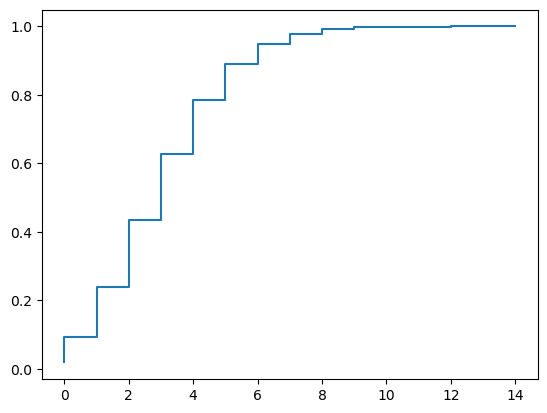

In [127]:
plt.step(x, stats.poisson.cdf(x, mu=lam))

#### Экспоненциальное распределение

In [128]:
scale = 1 / lam

In [133]:
x = np.linspace(0, 2, 20)

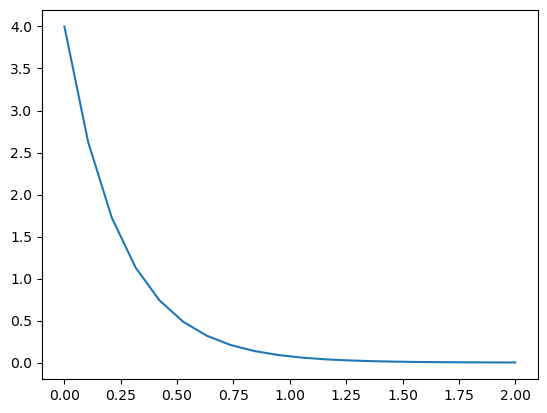

In [134]:
plt.plot(x, stats.expon.pdf(x, scale=scale))

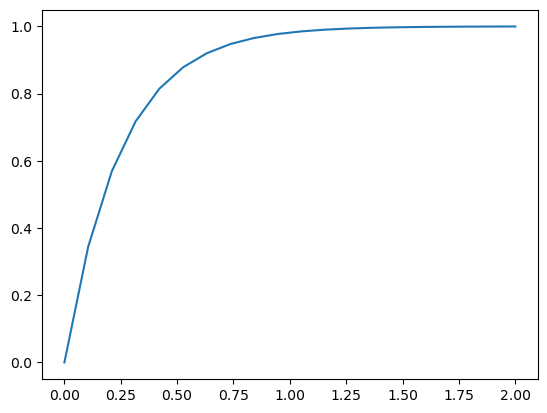

In [135]:
plt.plot(x, stats.expon.cdf(x, scale=scale))